In [152]:
pdb_file = '../../../data/GWTC-4_pop/analyses_BBH/BBHSpin_MagTruncnormIidTiltIsotropicTruncnormNid.h5'
res = popsummary.popresult.PopulationResult(fname=pdb_file)

logl = res.get_hyperparameter_samples(hyperparameters=["log_likelihood"])
maxl = np.argmax(logl)

def get(name):
    return res.get_hyperparameter_samples(
        hyperparameters=[name]
    )[maxl]
def get_median(name):
    return np.median(res.get_hyperparameter_samples(hyperparameters=[name]))

opening existing popsummary file: ../../../data/GWTC-4_pop/analyses_BBH/BBHSpin_MagTruncnormIidTiltIsotropicTruncnormNid.h5


## Spin sampler GWTC-4

In [140]:
from gwpopulation.models.spin import iid_spin_orientation_gaussian_isotropic
from gwpopulation.utils import truncnorm
from bilby.core.prior import Interped
import numpy as np

In [157]:
get_median('xi_spin')

0.6239175332834958

In [158]:
# spin_hyperpars = {'mu_chi': 0.103545,
#                   'sigma_chi': 0.339752,
#                   'mu_spin': 0.228621,
#                   'sigma_spin': 0.530840,
#                   'xi_spin': 0.940896}
# Median values
spin_hyperpars = {'mu_chi': 0.1,
                  'sigma_chi': 0.306,
                  'mu_spin': 0.4622,
                  'sigma_spin': 1.3768,
                  'xi_spin': 0.62392}

In [159]:
def sample_spin(num_samples, 
                mu_chi=spin_hyperpars['mu_chi'], 
                sigma_chi=spin_hyperpars['sigma_chi'], 
                mu_spin=spin_hyperpars['mu_spin'], 
                sigma_spin=spin_hyperpars['sigma_spin'], 
                xi_spin=spin_hyperpars['xi_spin'], 
                a_range = (0, 0.99),
                cos_tilt_range = (-1, 1)):
    num_samples = int(num_samples)
    a_i = np.random.uniform(a_range[0], a_range[1], 10000)
    dataset_i = {'cos_tilt_1': np.linspace(cos_tilt_range[0], cos_tilt_range[1], 10000),
                 'cos_tilt_2': np.linspace(cos_tilt_range[0], cos_tilt_range[1], 10000)}
    prob_ai = truncnorm(a_i, mu=mu_chi, sigma=sigma_chi, high=1, low=0)
    p_a = Interped(a_i, prob_ai, minimum=a_range[0], maximum=a_range[1])
    
    prob_cos_tilt = iid_spin_orientation_gaussian_isotropic(dataset=dataset_i, 
                                                            xi_spin=xi_spin, 
                                                            sigma_spin=sigma_spin, 
                                                            mu_spin=mu_spin)
    norm = np.trapz(prob_cos_tilt, dataset_i['cos_tilt_1'])
    prob_cos_tilt /= norm
    p_cos_tilt = Interped(dataset_i['cos_tilt_1'], prob_cos_tilt, 
                          minimum=cos_tilt_range[0], 
                          maximum=cos_tilt_range[1])
    
    samples = {'a_1': p_a.sample(num_samples),
               'a_2': p_a.sample(num_samples),
               'tilt_1': np.arccos(p_cos_tilt.sample(num_samples)),
               'tilt_2': np.arccos(p_cos_tilt.sample(num_samples))}
    return(samples)

In [160]:
my_samples = sample_spin(1e5)

## Compare against paper

In [161]:
import popsummary
import numpy as np

In [162]:
chi_grid_default, chi_rates_default   = res.get_rates_on_grids('a')
cost_grid_default, cost_rates_default = res.get_rates_on_grids('cos_tilt')
p_chi_default = np.median(chi_rates_default, axis=0)
p_cost_default = np.median(cost_rates_default, axis=0)

In [163]:
import pylab as plt

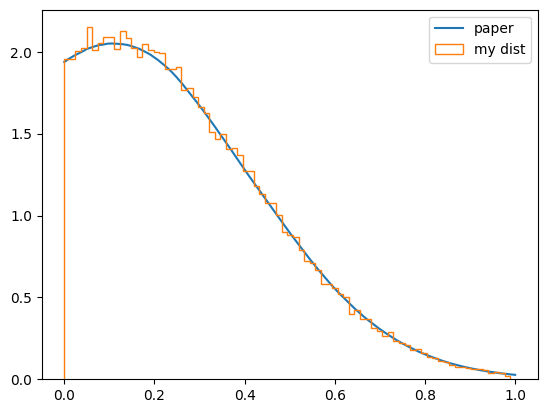

In [164]:
plt.plot(chi_grid_default[0], p_chi_default, label='paper')
plt.hist(my_samples['a_1'], density=True, bins=80, histtype='step', label='my dist');
plt.legend()

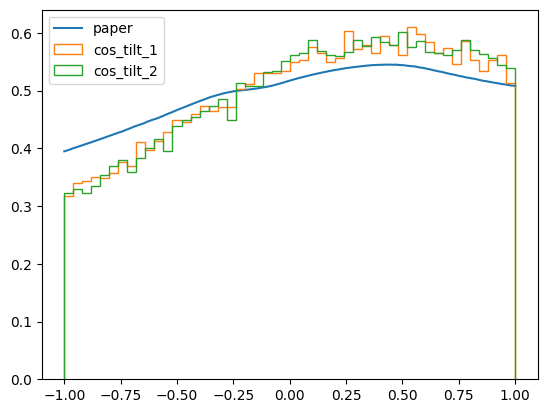

In [165]:
plt.plot(cost_grid_default[0], p_cost_default, label='paper')
plt.hist(np.cos(my_samples['tilt_1']), density=True, bins=50, histtype='step', label='cos_tilt_1');
plt.hist(np.cos(my_samples['tilt_2']), density=True, bins=50, histtype='step', label='cos_tilt_2');
plt.legend()